# Step 1: Importing necessary Python libraries.
 using Pandas, Numpy, Matplotlib and Seaborn libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Creating the data frame.

In [4]:
df = pd.read_csv("C:/Users/Rohit kumar/Downloads/Zomato-data-.csv")
print(df.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


# Step 3: Data Cleaning and Preparation
Before moving further we need to clean and process the data.

1. Convert the rate column to a float by removing denominator characters.

dataframe['rate']=dataframe['rate'].apply(handleRate): Applies the handleRate function to clean and convert each rating value in the 'rate' column.

In [6]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

df['rate']=df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


## 2. Getting summary of the dataframe use df.info().

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


## 3. Checking for missing or null values to identify any data gaps.

In [11]:
print(df.isnull().sum())

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


# Step 4: Exploring Restaurant Types
1. Let's see the listed_in (type) column to identify popular restaurant categories.

Text(0.5, 0, 'Type of restaurant')

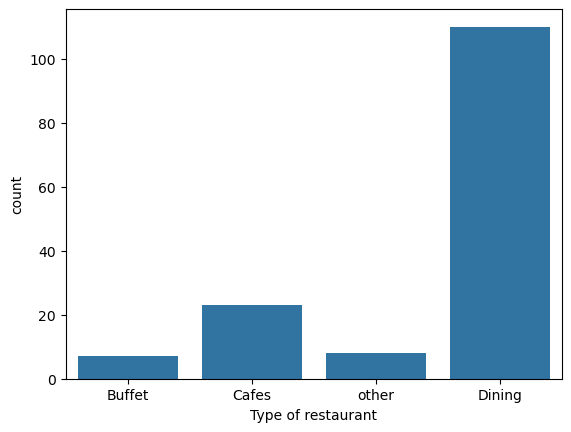

In [13]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of restaurant")

## 2. Votes by Restaurant Type

Here we get the count of votes for each category.

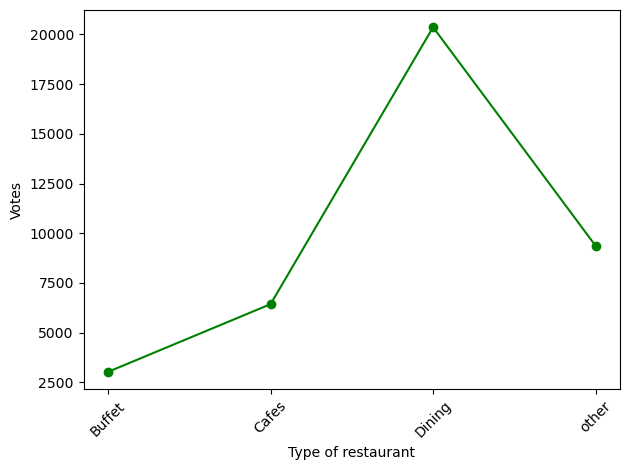

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Grouping votes by restaurant type
grouped_data = df.groupby('listed_in(type)')['votes'].sum()

# Converting to DataFrame
result = pd.DataFrame({'votes': grouped_data}).reset_index()

# Plotting (explicit x and y)
plt.plot(result['listed_in(type)'], result['votes'], c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')
plt.xticks(rotation=45)  # Rotate labels for readability
plt.tight_layout()
plt.show()


# Step 5: Identify the Most Voted Restaurant
Find the restaurant with the highest number of votes.

In [20]:
max_votes = df['votes'].max()
restaurant_with_max_votes = df.loc[df['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


# Step 6: Online Order Availability
Exploring the online_order column to see how many restaurants accept online orders.

<Axes: xlabel='online_order', ylabel='count'>

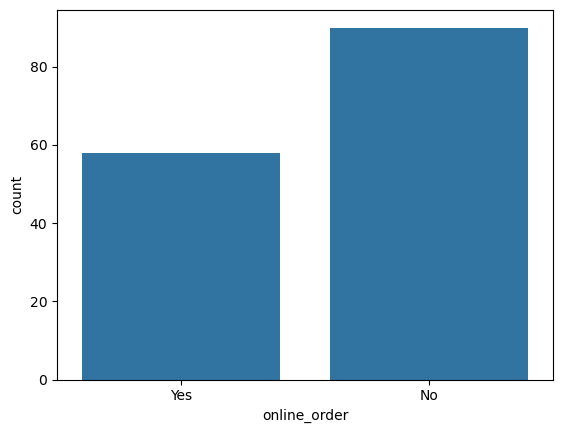

In [21]:
sns.countplot(x=df['online_order'])

# Step 7: Analyze Ratings
Checking the distribution of ratings from the rate column.

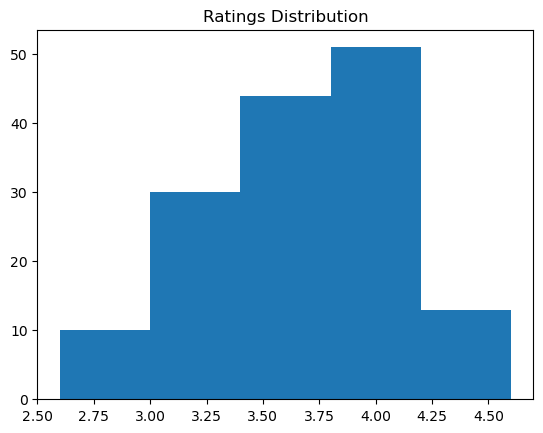

In [23]:
plt.hist(df['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

# Step 8: Approximate Cost for Couples
Analyze the approx_cost(for two people) column to find the preferred price range.

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

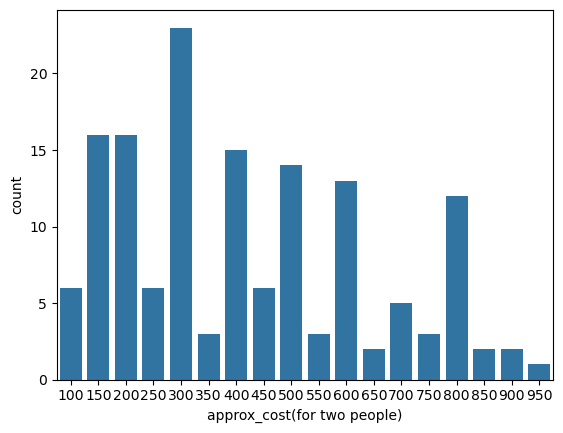

In [24]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)